- value : état complet du graphe après l'appel de chaque noeuds
- updates : met à jour l'état du graphe après l'appel de chaque noeuds

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END

# Reducers
from langgraph.graph.message import add_messages # Pour fusionner 2 listes de messages
from typing import Annotated

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
from dotenv import load_dotenv
load_dotenv()

import os

In [4]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0
)

In [5]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

def superbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

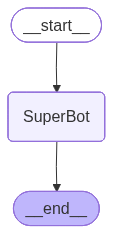

In [6]:
from IPython.display import Image, display

graph = StateGraph(State)

graph.add_node("SuperBot",superbot)

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

graph_memory = graph.compile(checkpointer=memory)

display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [7]:
config = {"configurable":{"thread_id":"1"}}

graph_memory.invoke({"messages":"Hy my name is Nicolas and I practice climbing"},config=config)

{'messages': [HumanMessage(content='Hy my name is Nicolas and I practice climbing', additional_kwargs={}, response_metadata={}, id='29195289-6f0b-4473-a0fe-5f0188f3d61b'),
  AIMessage(content='Hi Nicolas! That’s awesome that you practice climbing. How long have you been climbing, and what type of climbing do you enjoy most? (Bouldering, sport climbing, trad, or something else?)', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 16, 'total_tokens': 58, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c2f481d1ac', 'id': 'chatcmpl-Dr3F0FXqFfxcuOSGzQkKDjrlrzYPN', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ecbd5-4dd5-7d51-9d23-ffd02f233a

## Streaming the responses with stream method

In [8]:
config = {"configurable":{"thread_id":"2"}}

for chunk in graph_memory.stream({"messages":"Hy my name is Nicolas and I practice climbing"},config=config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hi Nicolas! That’s awesome that you practice climbing. How long have you been climbing, and what type of climbing do you enjoy most?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 16, 'total_tokens': 44, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c2f481d1ac', 'id': 'chatcmpl-Dr3FISmNP8JXK2ftQTBNZgNHLmpIO', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ecbd5-595a-7e21-b5d1-1937262b5cef-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 28, 'total_tokens': 44, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'

In [9]:
for chunk in graph_memory.stream({"messages":"Hy my name is Nicolas and I practice climbing"},config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hy my name is Nicolas and I practice climbing', additional_kwargs={}, response_metadata={}, id='dd64090a-3088-49a9-8e92-87d10d6f2cee'), AIMessage(content='Hi Nicolas! That’s awesome that you practice climbing. How long have you been climbing, and what type of climbing do you enjoy most?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 16, 'total_tokens': 44, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c2f481d1ac', 'id': 'chatcmpl-Dr3FISmNP8JXK2ftQTBNZgNHLmpIO', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ecbd5-595a-7e21-b5d1-1937262b5cef-0', tool_calls=[], invalid_tool_calls=[], usage_metada

Affiche tous les états

In [10]:
for chunk in graph_memory.stream({"messages":"Hy my name is Nicolas and I practice climbing and I also like trail running"},config=config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hi Nicolas! That’s a great combination—climbing and trail running both keep you strong and connected to nature. How long have you been into both, and do you have any favorite spots for climbing or running?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 124, 'total_tokens': 167, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_7b7cafbb56', 'id': 'chatcmpl-Dr3FXsfUlMxa275itPgkDZQlx4Jyg', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ecbd5-cacf-7f93-b331-e7c3471938b9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 124, 'output_tokens': 43, 'total_tokens': 167, 'in

Affiche la mise à jour récente de l'état

In [11]:
for chunk in graph_memory.stream({"messages":"I also like trail running"},config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hy my name is Nicolas and I practice climbing', additional_kwargs={}, response_metadata={}, id='dd64090a-3088-49a9-8e92-87d10d6f2cee'), AIMessage(content='Hi Nicolas! That’s awesome that you practice climbing. How long have you been climbing, and what type of climbing do you enjoy most?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 16, 'total_tokens': 44, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c2f481d1ac', 'id': 'chatcmpl-Dr3FISmNP8JXK2ftQTBNZgNHLmpIO', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ecbd5-595a-7e21-b5d1-1937262b5cef-0', tool_calls=[], invalid_tool_calls=[], usage_metada

## Streaming the response with astream method

Streaming tokens

Each event is a di t with a few keys:
- event : type og event that is being elmitted
- name : name of event
- data : data associated with the event
- metadata : node emitting the event

In [12]:
config = {"configurable":{"thread_id":"3"}}

async for event in graph_memory.astream_events({"messages":"Hi, my name is Nico and I like to practice climbing"},config=config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi, my name is Nico and I like to practice climbing'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ecbd6-2004-7763-9fde-f8c2cd644c06', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, my name is Nico and I like to practice climbing', additional_kwargs={}, response_metadata={}, id='82c950f7-0a6c-406d-8bcb-bfd1ca67b5f4')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019ecbd6-2006-77a2-8e07-f4b666cb8eb0', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:e1b917d8-2ed7-4ded-5fb5-8633d3562637'}, 'parent_ids': ['019ecbd6-2004-7763-9fde-f8c2cd644c06']}
{'event': 'on_chat_model_start', 'data': {'input': {'me